# GC3 Virtual Coach & Data Architect
## Master Golf Analysis - Interactive Notebook

**Golfer:** Zachariah Freitas  
**Analysis Date:** March 4, 2026  
**Data Source:** Foresight GC3 Launch Monitor  

---

This notebook provides comprehensive analysis of your golf swing data including:
- Shot dispersion and consistency metrics
- Swing flaw diagnosis based on Ball Flight Laws
- Personalized targets based on YOUR swing speed
- Visual pattern analysis with interactive charts
- Progress tracking across sessions

## 📚 Setup & Configuration

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.1f}'.format)

print("✅ Libraries imported successfully")
print("📊 Plotting configured")

✅ Libraries imported successfully
📊 Plotting configured


## 📂 Load GC3 Data

In [2]:
def parse_directional_value(value):
    """Parse directional values (e.g., '14.5 L', '6 R') into signed numbers."""
    if pd.isna(value) or value == '':
        return np.nan
    
    value_str = str(value).strip()
    try:
        num = float(value_str.split()[0])
    except (ValueError, IndexError):
        return np.nan
    
    # Left/Down/Out-to-In = negative, Right/Up/In-to-Out = positive
    if ' L' in value_str or ' DN' in value_str or 'O-I' in value_str:
        return -num
    elif ' R' in value_str or ' UP' in value_str or 'I-O' in value_str:
        return num
    else:
        return num

def parse_gc3_csv(filepath):
    """Parse a GC3 CSV file with custom header structure."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Extract metadata
    golfer_name = lines[0].split(',')[0]
    club = lines[2].split(',')[0].strip()
    
    # Read data starting from row 4
    df = pd.read_csv(filepath, skiprows=3)
    
    # Remove the average row (last row)
    df = df[df.iloc[:, 0] != 'Average'].copy()
    
    # Remove unnamed first column if it exists
    if df.columns[0] == '' or 'Unnamed' in str(df.columns[0]):
        df = df.iloc[:, 1:].copy()
    
    # Add metadata columns
    df.insert(0, 'Club', club)
    df.insert(0, 'Golfer', golfer_name)
    df.insert(0, 'Session_File', Path(filepath).stem)
    
    # Clean directional columns
    directional_columns = [
        'Offline', 'Curve', 'Launch Direction', 'Side Spin',
        'Spin Axis Tilt', 'Angle of Attack', 'Club Path',
        'Face to Path', 'Face to Target'
    ]
    
    for col in directional_columns:
        if col in df.columns:
            df[col] = df[col].apply(parse_directional_value)
    
    # Convert other numeric columns
    numeric_columns = [
        'Carry', 'Total', 'Peak Height', 'Descent Angle', 'Hang Time',
        'Ball Speed', 'Launch Angle', 'Back Spin', 'Total Spin',
        'Club Speed', 'Smash Factor'
    ]
    
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Parse date and time
    if 'Date' in df.columns and 'Time' in df.columns:
        df['DateTime'] = pd.to_datetime(
            df['Date'] + ' ' + df['Time'].str.split(' ').str[0],
            errors='coerce'
        )
    
    return df

# Load all session files
data_dir = Path.cwd()
csv_files = list(data_dir.glob('session_summary*.csv'))

all_sessions = []
for filepath in csv_files:
    df = parse_gc3_csv(filepath)
    all_sessions.append(df)
    print(f"✅ Loaded: {filepath.name} ({len(df)} shots)")

# Combine all sessions
df_all = pd.concat(all_sessions, ignore_index=True)

print(f"\n📊 Total shots loaded: {len(df_all)}")
print(f"🏌️ Clubs analyzed: {', '.join(df_all['Club'].unique())}")
print(f"📅 Sessions: {df_all['Session_File'].nunique()}")

✅ Loaded: session_summary20260214.csv (8 shots)
✅ Loaded: session_summary20260220.csv (21 shots)
✅ Loaded: session_summary20260227.csv (45 shots)
✅ Loaded: session_summary20260301.csv (36 shots)
✅ Loaded: session_summary20260302.csv (15 shots)

📊 Total shots loaded: 125
🏌️ Clubs analyzed: 7i
📅 Sessions: 5


In [3]:
# Preview the data
print("\n📋 Data Preview:")
df_all[['Club', 'Date', 'Carry', 'Ball Speed', 'Club Speed', 'Smash Factor', 
        'Launch Angle', 'Total Spin', 'Offline']].head(10)


📋 Data Preview:


,Club,Date,Carry,Ball Speed,Club Speed,Smash Factor,Launch Angle,Total Spin,Offline
0,7i,02/16/2026,61.7,61.9,NaN,NaN,25.7,2675,27.1
1,7i,02/16/2026,118.8,89.3,NaN,NaN,21.7,4674,-1.2
2,7i,02/16/2026,102.8,94.9,NaN,NaN,7.8,4850,2.5
3,7i,02/16/2026,138.7,101.0,NaN,NaN,18.3,5500,-13.2
4,7i,02/16/2026,126.8,93.0,NaN,NaN,21.6,4599,4.4
5,7i,02/16/2026,128.5,95.5,NaN,NaN,20.3,5724,-11.6
6,7i,02/16/2026,87.5,74.6,NaN,NaN,20.3,3149,-3.0
7,7i,02/16/2026,129.3,95.6,NaN,NaN,19.5,5199,-15.8
8,7i,02/20/2026,112.3,90.0,75.7,1.2,18.6,6225,-26.1
9,7i,02/20/2026,104.5,83.4,76.6,1.1,20.6,4375,-13.6


## 🎯 Calculate Derived Metrics

In [4]:
def diagnose_shot_shape(row):
    """Diagnose the shot shape based on path, face, and curve."""
    if pd.isna(row.get('Club Path')) or pd.isna(row.get('Face to Path')):
        return 'Unknown'
    
    path = row['Club Path']
    curve = row.get('Curve', 0)
    
    # Determine initial direction
    if path < -1:
        initial = 'Pull'
    elif path > 1:
        initial = 'Push'
    else:
        initial = 'Straight'
    
    # Determine curve
    if curve < -3:
        shape = 'Draw'
    elif curve > 3:
        shape = 'Fade'
    else:
        shape = 'Straight'
    
    if initial == 'Straight' and shape == 'Straight':
        return 'Straight'
    elif initial == 'Straight':
        return shape
    else:
        return f'{initial}-{shape}'

def assess_shot_quality(row):
    """Assess shot quality based on smash factor and dispersion."""
    smash = row.get('Smash Factor', 0)
    offline = abs(row.get('Offline', 0))
    carry_median = row.get('_carry_median', 120)  # Will be set later
    carry_error = abs(row.get('Carry', carry_median) - carry_median)
    
    if smash >= 1.38 and offline < 10 and carry_error < 8:
        return 'Excellent'
    elif smash >= 1.35 and offline < 15 and carry_error < 12:
        return 'Good'
    elif smash >= 1.30 and offline < 20 and carry_error < 15:
        return 'Average'
    elif smash >= 1.20:
        return 'Poor'
    else:
        return 'Mishit'

# Add derived metrics
df_all['Shot_Shape'] = df_all.apply(diagnose_shot_shape, axis=1)

# Calculate carry median for quality assessment
for club in df_all['Club'].unique():
    club_mask = df_all['Club'] == club
    carry_median = df_all.loc[club_mask, 'Carry'].median()
    df_all.loc[club_mask, '_carry_median'] = carry_median

df_all['Shot_Quality'] = df_all.apply(assess_shot_quality, axis=1)

# Calculate distance error and total error
for club in df_all['Club'].unique():
    club_mask = df_all['Club'] == club
    carry_avg = df_all.loc[club_mask, 'Carry'].median()
    df_all.loc[club_mask, 'Distance_Error'] = df_all.loc[club_mask, 'Carry'] - carry_avg
    df_all.loc[club_mask, 'Total_Error'] = np.sqrt(
        df_all.loc[club_mask, 'Distance_Error']**2 + 
        df_all.loc[club_mask, 'Offline']**2
    )

print("✅ Derived metrics calculated")
print(f"\n📊 Shot Shape Distribution:")
print(df_all['Shot_Shape'].value_counts())
print(f"\n⭐ Shot Quality Distribution:")
print(df_all['Shot_Quality'].value_counts())

✅ Derived metrics calculated

📊 Shot Shape Distribution:
Shot_Shape
Unknown    125
Name: count, dtype: int64

⭐ Shot Quality Distribution:
Shot_Quality
Poor       58
Mishit     49
Average    17
Good        1
Name: count, dtype: int64


## 📊 Summary Statistics

In [5]:
# Filter out mishits for "true averages"
df_clean = df_all[df_all['Smash Factor'] >= 1.20].copy()

# Calculate statistics by club
stats_by_club = []

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    stats = {
        'Club': club,
        'Shots': len(club_data),
        'Carry (avg)': club_data['Carry'].mean(),
        'Carry (std)': club_data['Carry'].std(),
        'Ball Speed': club_data['Ball Speed'].mean(),
        'Club Speed': club_data['Club Speed'].mean(),
        'Smash Factor': club_data['Smash Factor'].mean(),
        'Launch Angle': club_data['Launch Angle'].mean(),
        'Total Spin': club_data['Total Spin'].mean(),
        'Attack Angle': club_data['Angle of Attack'].mean(),
        'Club Path': club_data['Club Path'].mean(),
        'Face to Path': club_data['Face to Path'].mean(),
        'Offline (avg)': club_data['Offline'].mean(),
        'Offline (std)': club_data['Offline'].abs().std(),
    }
    stats_by_club.append(stats)

df_stats = pd.DataFrame(stats_by_club)

# Style the dataframe
def color_smash(val):
    if val < 1.30:
        color = 'background-color: #FFC7CE; color: #9C0006'  # Red
    elif val < 1.35:
        color = 'background-color: #FFEB9C; color: #9C5700'  # Yellow
    elif val < 1.38:
        color = 'background-color: #C6EFCE; color: #006100'  # Light green
    else:
        color = 'background-color: #00B050; color: white'      # Dark green
    return color

styled_stats = df_stats.style.format({
    'Carry (avg)': '{:.1f}',
    'Carry (std)': '{:.1f}',
    'Ball Speed': '{:.1f}',
    'Club Speed': '{:.1f}',
    'Smash Factor': '{:.2f}',
    'Launch Angle': '{:.1f}',
    'Total Spin': '{:.0f}',
    'Attack Angle': '{:.1f}',
    'Club Path': '{:.1f}',
    'Face to Path': '{:.1f}',
    'Offline (avg)': '{:.1f}',
    'Offline (std)': '{:.1f}',
}).applymap(color_smash, subset=['Smash Factor'])

print("\n📈 SUMMARY STATISTICS (Outliers Removed)")
print("="*80)
styled_stats


📈 SUMMARY STATISTICS (Outliers Removed)


,Club,Shots,Carry (avg),Carry (std),Ball Speed,Club Speed,Smash Factor,Launch Angle,Total Spin,Attack Angle,Club Path,Face to Path,Offline (avg),Offline (std)
0,7i,76,127.2,21.4,97.7,74.8,1.31,17.3,4924,-4.4,-0.2,nan,-9.2,9.8


## 🎯 Personalized Targets (Based on YOUR Swing Speed)

In [6]:
# PGA Tour Benchmarks
TOUR_BENCHMARKS = {
    'Driver': {'club_speed': 113, 'ball_speed': 167, 'carry': 275, 'launch': 10.9, 'spin': 2686, 'smash': 1.48, 'aoa': 3.0},
    '7i': {'club_speed': 87, 'ball_speed': 120, 'carry': 172, 'launch': 16.3, 'spin': 7097, 'smash': 1.38, 'aoa': -4.3},
    'PW': {'club_speed': 73, 'ball_speed': 102, 'carry': 136, 'launch': 24.2, 'spin': 9304, 'smash': 1.39, 'aoa': -5.0},
}

def calculate_personalized_targets(club, actual_club_speed, tour_data):
    """Calculate personalized targets based on actual swing speed."""
    tour_club_speed = tour_data['club_speed']
    speed_ratio = actual_club_speed / tour_club_speed
    
    # Optimal metrics
    optimal_smash = tour_data['smash']
    optimal_ball_speed = actual_club_speed * optimal_smash
    
    # Distance scales with speed (slightly exponential)
    distance_ratio = speed_ratio ** 1.05
    optimal_carry = tour_data['carry'] * distance_ratio
    
    # Launch adjustments for slower speeds
    if speed_ratio < 0.85:
        launch_adjustment = 2.0
        spin_ratio = 1.10
    elif speed_ratio < 0.95:
        launch_adjustment = 1.0
        spin_ratio = 1.05
    else:
        launch_adjustment = 0
        spin_ratio = 1.0
    
    optimal_launch = tour_data['launch'] + launch_adjustment
    optimal_spin = tour_data['spin'] * spin_ratio
    optimal_aoa = tour_data['aoa']
    
    # Speed category
    if speed_ratio >= 1.05:
        category = 'Tour+'
    elif speed_ratio >= 0.95:
        category = 'Tour Average'
    elif speed_ratio >= 0.85:
        category = 'Competitive Amateur'
    elif speed_ratio >= 0.75:
        category = 'Average Amateur'
    elif speed_ratio >= 0.65:
        category = 'Recreational'
    else:
        category = 'Beginner'
    
    return {
        'club_speed': actual_club_speed,
        'ball_speed': optimal_ball_speed,
        'smash': optimal_smash,
        'carry': optimal_carry,
        'launch': optimal_launch,
        'spin': optimal_spin,
        'aoa': optimal_aoa,
        'speed_ratio': speed_ratio,
        'category': category
    }

# Calculate personalized targets for each club
personalized_targets = []

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    # Map club names
    club_key = club.replace('i', 'i') if 'i' in club else club
    
    if club_key in TOUR_BENCHMARKS:
        avg_club_speed = club_data['Club Speed'].mean()
        targets = calculate_personalized_targets(club, avg_club_speed, TOUR_BENCHMARKS[club_key])
        
        # Get actuals
        actuals = {
            'Club': club,
            'Category': targets['category'],
            'Speed Ratio': f"{targets['speed_ratio']:.2f}x",
            'Your Carry': club_data['Carry'].mean(),
            'Target Carry': targets['carry'],
            'Gap': targets['carry'] - club_data['Carry'].mean(),
            'Your Smash': club_data['Smash Factor'].mean(),
            'Target Smash': targets['smash'],
            'Your Launch': club_data['Launch Angle'].mean(),
            'Target Launch': targets['launch'],
            'Your Spin': club_data['Total Spin'].mean(),
            'Target Spin': targets['spin'],
        }
        personalized_targets.append(actuals)

df_targets = pd.DataFrame(personalized_targets)

# Style the targets
def color_gap(val):
    if val < 0:
        return 'background-color: #00B050; color: white'  # Above target
    elif val < 10:
        return 'background-color: #C6EFCE'  # Close to target
    elif val < 20:
        return 'background-color: #FFEB9C'  # Moderate gap
    else:
        return 'background-color: #FFC7CE'  # Large gap

print("\n🎯 PERSONALIZED TARGETS (Based on YOUR Swing Speed)")
print("="*80)
print("\nThese targets are calculated from YOUR actual club speed,")
print("not PGA Tour averages. This is what YOU can achieve!\n")

styled_targets = df_targets.style.format({
    'Your Carry': '{:.1f}',
    'Target Carry': '{:.1f}',
    'Gap': '{:+.1f}',
    'Your Smash': '{:.2f}',
    'Target Smash': '{:.2f}',
    'Your Launch': '{:.1f}',
    'Target Launch': '{:.1f}',
    'Your Spin': '{:.0f}',
    'Target Spin': '{:.0f}',
}).applymap(color_gap, subset=['Gap']).applymap(color_smash, subset=['Your Smash'])

styled_targets


🎯 PERSONALIZED TARGETS (Based on YOUR Swing Speed)

These targets are calculated from YOUR actual club speed,
not PGA Tour averages. This is what YOU can achieve!



,Club,Category,Speed Ratio,Your Carry,Target Carry,Gap,Your Smash,Target Smash,Your Launch,Target Launch,Your Spin,Target Spin
0,7i,Competitive Amateur,0.86x,127.2,146.8,+19.6,1.31,1.38,17.3,17.3,4924,7452


## 🔍 Swing Flaw Diagnosis

In [7]:
def identify_swing_flaws(club_data, club_name):
    """Identify mechanical swing flaws based on data patterns."""
    flaws = []
    
    # Face-to-Path Analysis
    avg_face = club_data['Face to Path'].mean()
    avg_path = club_data['Club Path'].mean()
    
    if abs(avg_face) > 2:
        if avg_face > 2:
            flaws.append({
                'Priority': '🔴 HIGH' if avg_face > 4 else '🟡 MEDIUM',
                'Category': 'Face Control',
                'Issue': f'Face too open at impact ({avg_face:.1f}°)',
                'Fix': 'Work on grip strength and wrist rotation through impact'
            })
        else:
            flaws.append({
                'Priority': '🔴 HIGH' if avg_face < -4 else '🟡 MEDIUM',
                'Category': 'Face Control',
                'Issue': f'Face too closed at impact ({avg_face:.1f}°)',
                'Fix': 'Check grip is not too strong, maintain face angle through impact'
            })
    
    if abs(avg_path) > 3:
        if avg_path > 3:
            flaws.append({
                'Priority': '🟡 MEDIUM',
                'Category': 'Swing Path',
                'Issue': f'Excessive in-to-out path ({avg_path:.1f}°)',
                'Fix': 'Work on swing plane, focus on on-plane delivery'
            })
        else:
            flaws.append({
                'Priority': '🟡 MEDIUM',
                'Category': 'Swing Path',
                'Issue': f'Excessive out-to-in path ({avg_path:.1f}°)',
                'Fix': 'Path too leftward - work on inside delivery, avoid over-the-top'
            })
    
    # Smash Factor Analysis
    avg_smash = club_data['Smash Factor'].mean()
    if avg_smash < 1.35:
        flaws.append({
            'Priority': '🔴 HIGH',
            'Category': 'Contact Quality',
            'Issue': f'Low smash factor ({avg_smash:.2f} vs target 1.38)',
            'Fix': 'Focus on center-face contact - use impact tape/spray'
        })
    
    # Angle of Attack Analysis
    avg_aoa = club_data['Angle of Attack'].mean()
    aoa_std = club_data['Angle of Attack'].std()
    
    if avg_aoa > -2:  # Should be descending for irons
        flaws.append({
            'Priority': '🟡 MEDIUM',
            'Category': 'Angle of Attack',
            'Issue': f'Insufficient downward strike ({avg_aoa:.1f}°)',
            'Fix': 'Need more descending blow - ball-first contact, hands ahead'
        })
    
    if aoa_std > 2.5:
        flaws.append({
            'Priority': '🟡 MEDIUM',
            'Category': 'Consistency',
            'Issue': f'Inconsistent attack angle (std dev {aoa_std:.1f}°)',
            'Fix': 'Work on consistent low point and setup position'
        })
    
    # Spin Rate Analysis
    avg_spin = club_data['Total Spin'].mean()
    if avg_spin < 5500:
        flaws.append({
            'Priority': '🟡 MEDIUM',
            'Category': 'Spin Rate',
            'Issue': f'Insufficient spin ({avg_spin:.0f} RPM vs 6500-7500 target)',
            'Fix': 'Increase spin loft - may need steeper AoA or check club condition'
        })
    elif avg_spin > 7500:
        flaws.append({
            'Priority': '🟡 MEDIUM',
            'Category': 'Spin Rate',
            'Issue': f'Excessive spin ({avg_spin:.0f} RPM - ballooning)',
            'Fix': 'Reduce spin loft - hands ahead at impact, avoid scooping'
        })
    
    # Dispersion Analysis
    offline_std = club_data['Offline'].abs().std()
    offline_mean = club_data['Offline'].mean()
    
    if offline_std > 12:
        flaws.append({
            'Priority': '🔴 HIGH',
            'Category': 'Dispersion',
            'Issue': f'Poor lateral consistency (std dev {offline_std:.1f} yards)',
            'Fix': 'Large offline scatter - work on face control and path consistency'
        })
    
    if abs(offline_mean) > 8:
        direction = 'left' if offline_mean < 0 else 'right'
        flaws.append({
            'Priority': '🟡 MEDIUM',
            'Category': 'Dispersion',
            'Issue': f'Consistent miss {direction} ({abs(offline_mean):.1f}y average)',
            'Fix': f'Check alignment and face-to-path relationship'
        })
    
    carry_std = club_data['Carry'].std()
    if carry_std > 10:
        flaws.append({
            'Priority': '🟡 MEDIUM',
            'Category': 'Distance Control',
            'Issue': f'Inconsistent carry distance (std dev {carry_std:.1f} yards)',
            'Fix': 'Focus on consistent contact and tempo'
        })
    
    if not flaws:
        flaws.append({
            'Priority': '✅ GOOD',
            'Category': 'Overall',
            'Issue': 'No major flaws detected',
            'Fix': 'Continue current practice routine'
        })
    
    return flaws

# Identify flaws for each club
print("\n🔍 SWING FLAW DIAGNOSIS")
print("="*80)

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    flaws = identify_swing_flaws(club_data, club)
    
    print(f"\n{'='*80}")
    print(f"🏌️ {club} ANALYSIS")
    print(f"{'='*80}")
    
    df_flaws = pd.DataFrame(flaws)
    
    for _, flaw in df_flaws.iterrows():
        print(f"\n{flaw['Priority']} {flaw['Category']}")
        print(f"   Issue: {flaw['Issue']}")
        print(f"   Fix:   {flaw['Fix']}")


🔍 SWING FLAW DIAGNOSIS

🏌️ 7i ANALYSIS

🔴 HIGH Contact Quality
   Issue: Low smash factor (1.31 vs target 1.38)
   Fix:   Focus on center-face contact - use impact tape/spray

🟡 MEDIUM Spin Rate
   Issue: Insufficient spin (4924 RPM vs 6500-7500 target)
   Fix:   Increase spin loft - may need steeper AoA or check club condition

🟡 MEDIUM Dispersion
   Issue: Consistent miss left (9.2y average)
   Fix:   Check alignment and face-to-path relationship

🟡 MEDIUM Distance Control
   Issue: Inconsistent carry distance (std dev 21.4 yards)
   Fix:   Focus on consistent contact and tempo


## 📊 Visual Analysis - Interactive Charts

### Chart 1: Shot Dispersion Map (Bird's Eye View)

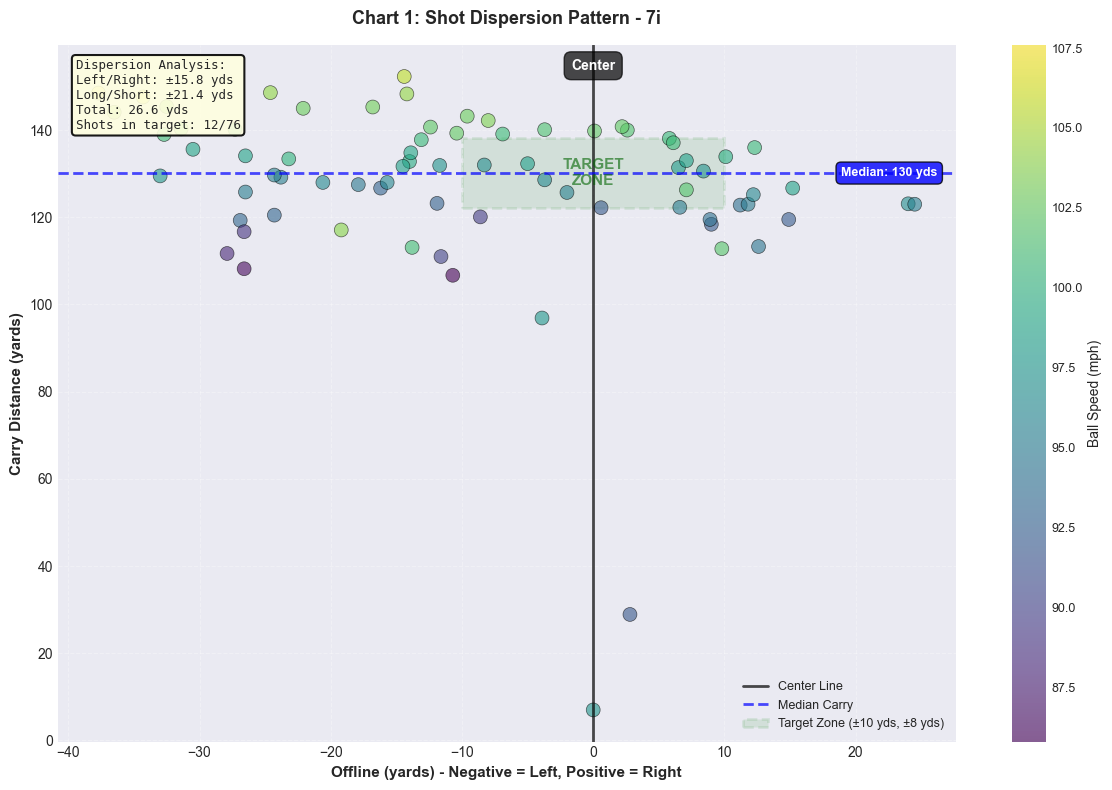

Chart 1: Shot Dispersion - Enhanced ✓


In [8]:
newline = chr(10)

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatter plot with color mapping
    scatter = ax.scatter(club_data['Offline'], club_data['Carry'],
                        c=club_data['Ball Speed'], cmap='viridis',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Reference lines
    ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.7, label='Center Line', zorder=1)
    median_carry = club_data['Carry'].median()
    ax.axhline(y=median_carry, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Median Carry', zorder=1)
    
    # Target zone (±10 yards left/right, ±8 yards carry)
    from matplotlib.patches import Rectangle
    target_width = 20  # ±10 yards
    target_height = 16  # ±8 yards
    target_box = Rectangle((-10, median_carry - 8), target_width, target_height,
                          fill=True, facecolor='green', alpha=0.1, edgecolor='green',
                          linewidth=2, linestyle='--', label='Target Zone (±10 yds, ±8 yds)', zorder=0)
    ax.add_patch(target_box)
    
    # Annotations for reference lines
    ax.text(0, ax.get_ylim()[1]*0.98, 'Center', ha='center', va='top', fontsize=10,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))
    ax.text(ax.get_xlim()[1]*0.95, median_carry, f'Median: {median_carry:.0f} yds',
            va='center', ha='right', fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='blue', alpha=0.8))
    
    # Target zone label
    ax.text(0, median_carry, f'TARGET{newline}ZONE', ha='center', va='center', fontsize=11, fontweight='bold', color='darkgreen', alpha=0.6)
    
    # Calculate and display dispersion stats
    std_offline = club_data['Offline'].std()
    std_carry = club_data['Carry'].std()
    total_dispersion = np.sqrt(std_offline**2 + std_carry**2)
    
    stats_text = (
        f'Dispersion Analysis:{newline}'
        f'Left/Right: ±{std_offline:.1f} yds{newline}'
        f'Long/Short: ±{std_carry:.1f} yds{newline}'
        f'Total: {total_dispersion:.1f} yds{newline}'
        f'Shots in target: {len(club_data[(abs(club_data["Offline"]) <= 10) & (abs(club_data["Carry"] - median_carry) <= 8)])}/{len(club_data)}'
    )
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    # Formatting
    ax.set_xlabel('Offline (yards) - Negative = Left, Positive = Right', fontsize=11, fontweight='bold')
    ax.set_ylabel('Carry Distance (yards)', fontsize=11, fontweight='bold')
    ax.set_title(f'Chart 1: Shot Dispersion Pattern - {club}', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Ball Speed (mph)')
    cbar.ax.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.show()

print('Chart 1: Shot Dispersion - Enhanced ✓')


### Chart 2a: Curve vs Offline Position

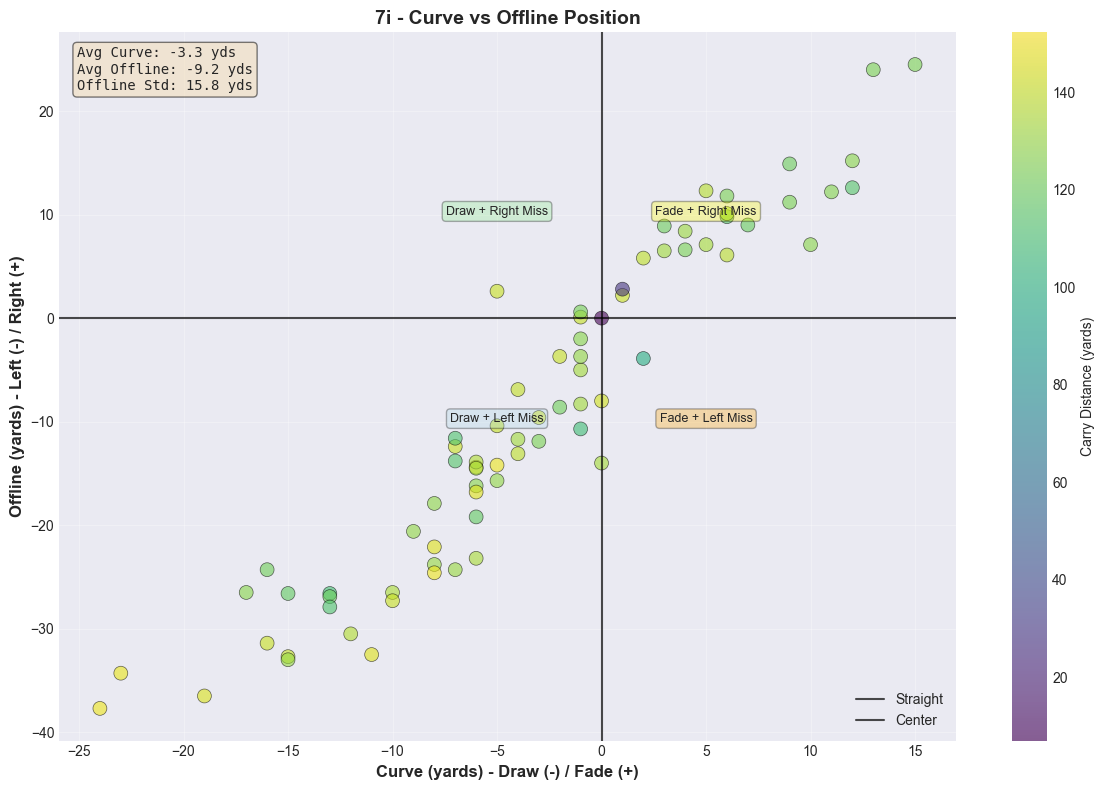

Chart 2: Curve vs Offline for 7i
Shows relationship between ball curve and lateral position.


In [9]:
for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(club_data['Curve'], club_data['Offline'],
                        c=club_data['Carry'], cmap='viridis',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, label='Straight')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, label='Center')
    ax.text(5, 10, 'Fade + Right Miss', fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    ax.text(5, -10, 'Fade + Left Miss', fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
    ax.text(-5, 10, 'Draw + Right Miss', fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
    ax.text(-5, -10, 'Draw + Left Miss', fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    ax.set_xlabel('Curve (yards) - Draw (-) / Fade (+)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Offline (yards) - Left (-) / Right (+)', fontsize=12, fontweight='bold')
    ax.set_title(f'{club} - Curve vs Offline Position', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Carry Distance (yards)', fontsize=10)
    curve_mean = club_data['Curve'].mean()
    offline_mean = club_data['Offline'].mean()
    offline_std = club_data['Offline'].std()
    newline = chr(10)
    stats_text = f'Avg Curve: {curve_mean:.1f} yds{newline}Avg Offline: {offline_mean:.1f} yds{newline}Offline Std: {offline_std:.1f} yds'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=10, family='monospace')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Chart 2: Curve vs Offline for {club}')
    print('Shows relationship between ball curve and lateral position.')

In [ ]:
asdfasfdfdff ### Chart 2b: Curve vs Launch Direction

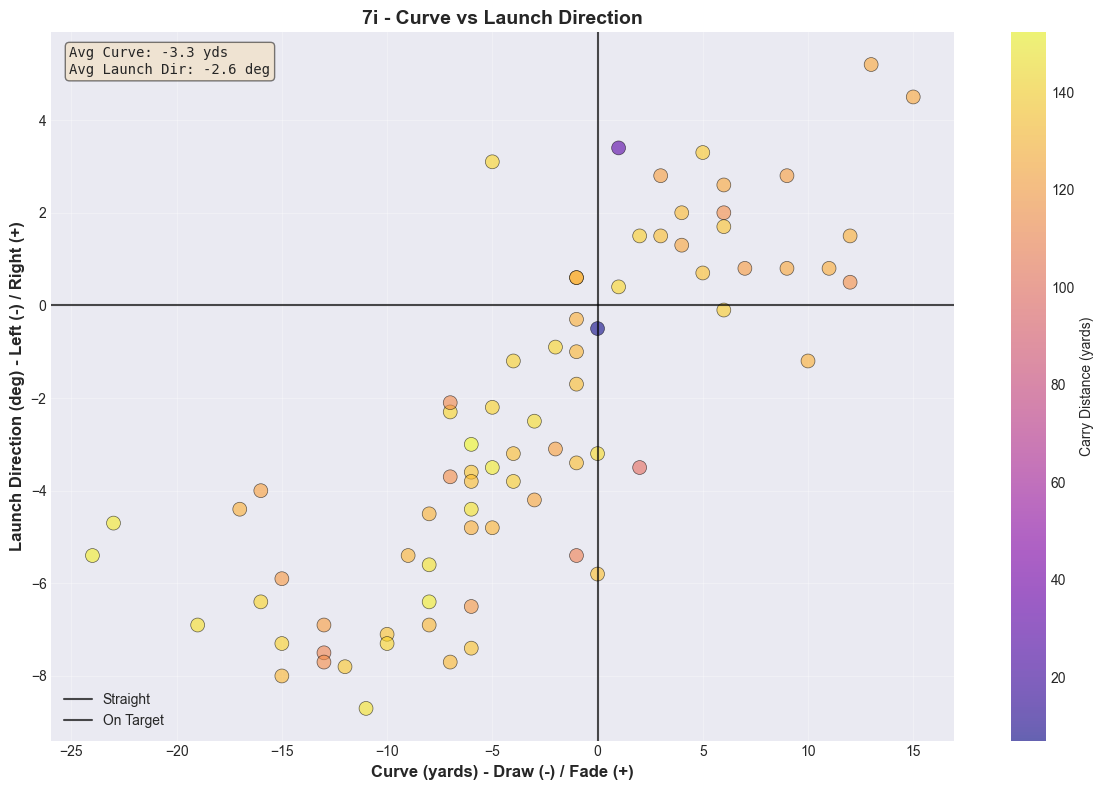

Chart 2b: Curve vs Launch Direction for 7i


In [10]:
for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(club_data['Curve'], club_data['Launch Direction'],
                        c=club_data['Carry'], cmap='plasma',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, label='Straight')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, label='On Target')
    ax.set_xlabel('Curve (yards) - Draw (-) / Fade (+)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Launch Direction (deg) - Left (-) / Right (+)', fontsize=12, fontweight='bold')
    ax.set_title(f'{club} - Curve vs Launch Direction', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Carry Distance (yards)', fontsize=10)
    curve_mean = club_data['Curve'].mean()
    launch_mean = club_data['Launch Direction'].mean()
    newline = chr(10)
    stats_text = f'Avg Curve: {curve_mean:.1f} yds{newline}Avg Launch Dir: {launch_mean:.1f} deg'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=10, family='monospace')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Chart 2b: Curve vs Launch Direction for {club}')

### Chart 2c: Curve vs Side Spin

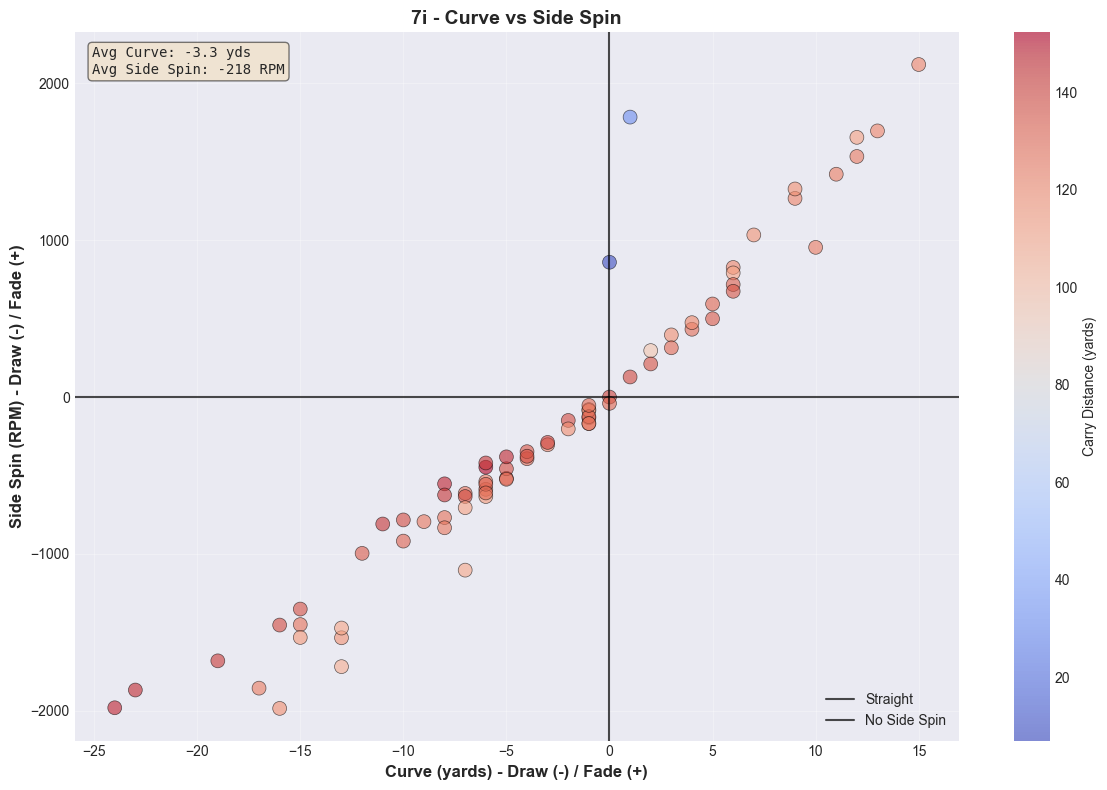

Chart 2c: Curve vs Side Spin for 7i


In [11]:
for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(club_data['Curve'], club_data['Side Spin'],
                        c=club_data['Carry'], cmap='coolwarm',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, label='Straight')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, label='No Side Spin')
    ax.set_xlabel('Curve (yards) - Draw (-) / Fade (+)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Side Spin (RPM) - Draw (-) / Fade (+)', fontsize=12, fontweight='bold')
    ax.set_title(f'{club} - Curve vs Side Spin', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Carry Distance (yards)', fontsize=10)
    curve_mean = club_data['Curve'].mean()
    sidespin_mean = club_data['Side Spin'].mean()
    newline = chr(10)
    stats_text = f'Avg Curve: {curve_mean:.1f} yds{newline}Avg Side Spin: {sidespin_mean:.0f} RPM'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=10, family='monospace')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Chart 2c: Curve vs Side Spin for {club}')

### Chart 3: Efficiency Analysis (Smash Factor vs Spin)

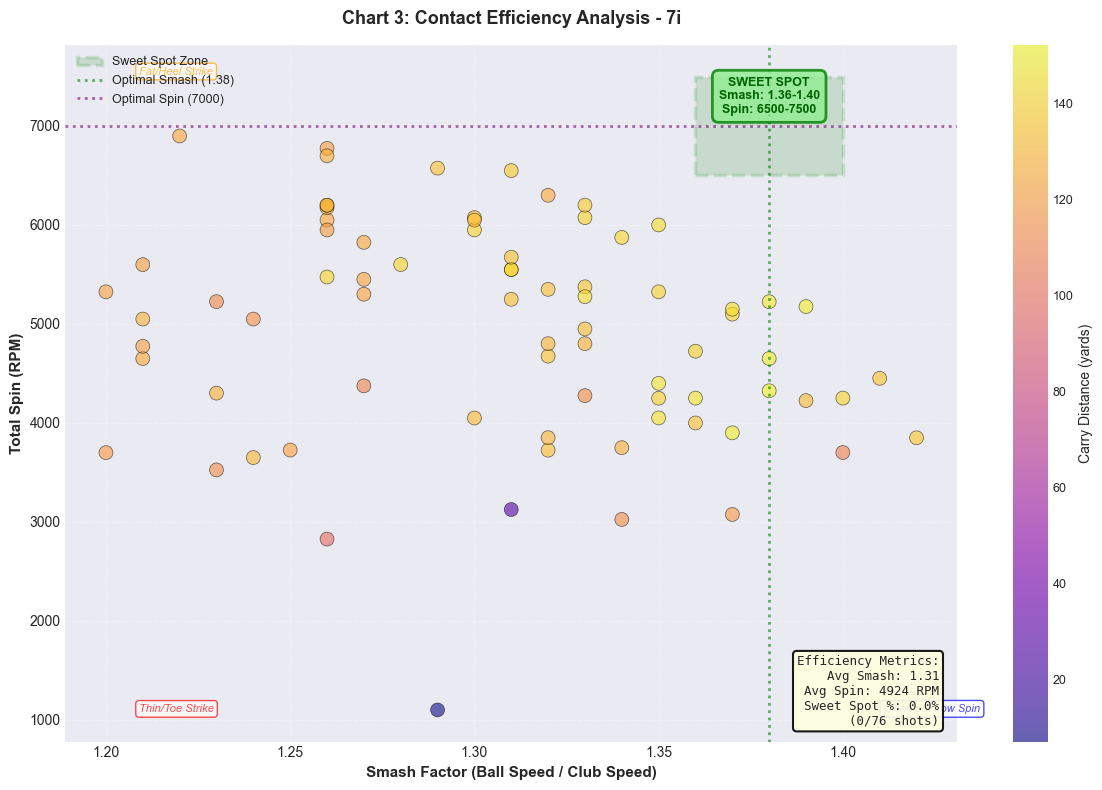

Chart 3: Efficiency Analysis - Enhanced ✓


In [12]:
newline = chr(10)

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatter plot
    scatter = ax.scatter(club_data['Smash Factor'], club_data['Total Spin'],
                        c=club_data['Carry'], cmap='plasma',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Target box (Sweet Spot Zone)
    from matplotlib.patches import Rectangle
    sweet_spot = Rectangle((1.36, 6500), 0.04, 1000,
                           fill=True, facecolor='green', alpha=0.15,
                           edgecolor='green', linewidth=2.5, linestyle='--',
                           label='Sweet Spot Zone', zorder=0)
    ax.add_patch(sweet_spot)
    
    # Target box label with arrow
    ax.text(1.38, 7500, f'SWEET SPOT{newline}Smash: 1.36-1.40{newline}Spin: 6500-7500',
            fontsize=9, fontweight='bold', va='top', ha='center', color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8, edgecolor='green', linewidth=2))
    
    # Reference lines
    ax.axvline(x=1.38, color='green', linestyle=':', linewidth=2, alpha=0.6, label='Optimal Smash (1.38)')
    ax.axhline(y=7000, color='purple', linestyle=':', linewidth=2, alpha=0.6, label='Optimal Spin (7000)')
    
    # Quadrant labels for diagnosis
    y_mid = (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2
    x_mid = (ax.get_xlim()[0] + ax.get_xlim()[1]) / 2
    
    # Lower left quadrant
    ax.text(ax.get_xlim()[0] + 0.02, ax.get_ylim()[0] + 300,
            'Thin/Toe Strike', fontsize=8, style='italic', color='red', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='red'))
    
    # Upper left quadrant
    ax.text(ax.get_xlim()[0] + 0.02, ax.get_ylim()[1] - 300,
            'Fat/Heel Strike', fontsize=8, style='italic', color='orange', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='orange'))
    
    # Lower right quadrant
    ax.text(ax.get_xlim()[1] - 0.02, ax.get_ylim()[0] + 300,
            'Clean but Low Spin', fontsize=8, style='italic', color='blue', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='blue'))
    
    # Calculate efficiency stats
    in_sweet_spot = len(club_data[(club_data['Smash Factor'] >= 1.36) & 
                                   (club_data['Smash Factor'] <= 1.40) &
                                   (club_data['Total Spin'] >= 6500) &
                                   (club_data['Total Spin'] <= 7500)])
    
    stats_text = (
        f'Efficiency Metrics:{newline}'
        f'Avg Smash: {club_data["Smash Factor"].mean():.2f}{newline}'
        f'Avg Spin: {club_data["Total Spin"].mean():.0f} RPM{newline}'
        f'Sweet Spot %: {100*in_sweet_spot/len(club_data):.1f}%{newline}'
        f'({in_sweet_spot}/{len(club_data)} shots)'
    )
    ax.text(0.98, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', horizontalalignment='right', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    # Formatting
    ax.set_xlabel('Smash Factor (Ball Speed / Club Speed)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Spin (RPM)', fontsize=11, fontweight='bold')
    ax.set_title(f'Chart 3: Contact Efficiency Analysis - {club}', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Carry Distance (yards)')
    cbar.ax.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.show()

print('Chart 3: Efficiency Analysis - Enhanced ✓')


### Chart 4: Attack Angle vs Launch Angle

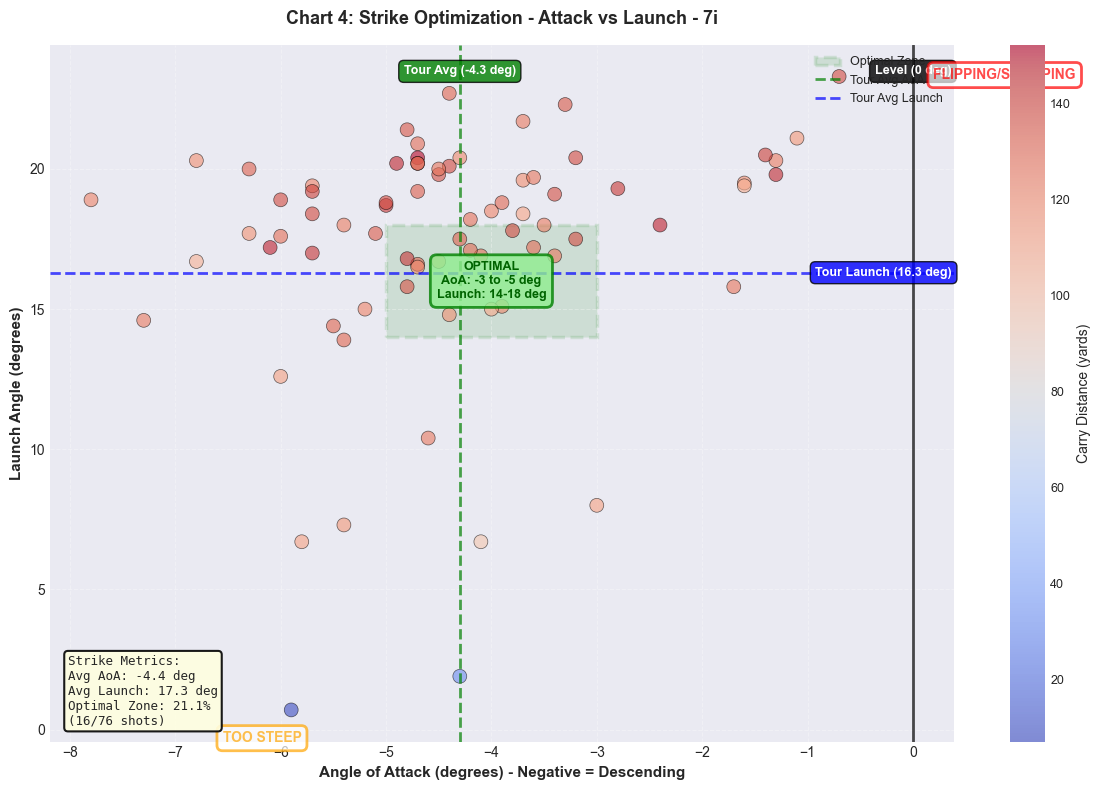

Chart 4: Attack Angle vs Launch - Enhanced ✓


In [13]:
newline = chr(10)

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatter plot
    scatter = ax.scatter(club_data['Angle of Attack'], club_data['Launch Angle'],
                        c=club_data['Carry'], cmap='coolwarm',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Optimal zone for 7-iron
    from matplotlib.patches import Rectangle
    optimal_zone = Rectangle((-5, 14), 2, 4,
                            fill=True, facecolor='green', alpha=0.12,
                            edgecolor='green', linewidth=2.5, linestyle='--',
                            label='Optimal Zone', zorder=0)
    ax.add_patch(optimal_zone)
    
    # Reference lines
    ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.7, zorder=1)
    ax.axvline(x=-4.3, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Tour Avg AoA', zorder=1)
    ax.axhline(y=16.3, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Tour Avg Launch', zorder=1)
    
    # Annotations
    ax.text(0, ax.get_ylim()[1]*0.97, 'Level (0 deg)', ha='center', va='top', fontsize=9,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))
    ax.text(-4.3, ax.get_ylim()[1]*0.97, 'Tour Avg (-4.3 deg)', ha='center', va='top', fontsize=9,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='green', alpha=0.8))
    ax.text(ax.get_xlim()[1]*0.95, 16.3, 'Tour Launch (16.3 deg)', va='center', ha='right',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='blue', alpha=0.8))
    
    # Optimal zone label
    ax.text(-4, 16, f'OPTIMAL{newline}AoA: -3 to -5 deg{newline}Launch: 14-18 deg',
            fontsize=9, fontweight='bold', ha='center', va='center', color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8, edgecolor='green', linewidth=2))
    
    # Problem zone indicators
    if ax.get_xlim()[1] > 0:
        ax.text(ax.get_xlim()[1]*0.5, ax.get_ylim()[1]*0.95,
                'FLIPPING/SCOOPING', fontsize=10, fontweight='bold', color='red', alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='red', linewidth=2))
    
    if ax.get_xlim()[0] < -7:
        ax.text(ax.get_xlim()[0]*0.8, ax.get_ylim()[0]*1.05,
                'TOO STEEP', fontsize=10, fontweight='bold', color='orange', alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='orange', linewidth=2))
    
    # Stats
    in_optimal = len(club_data[(club_data['Angle of Attack'] >= -5) &
                               (club_data['Angle of Attack'] <= -3) &
                               (club_data['Launch Angle'] >= 14) &
                               (club_data['Launch Angle'] <= 18)])
    
    stats_text = (
        f'Strike Metrics:{newline}'
        f'Avg AoA: {club_data["Angle of Attack"].mean():.1f} deg{newline}'
        f'Avg Launch: {club_data["Launch Angle"].mean():.1f} deg{newline}'
        f'Optimal Zone: {100*in_optimal/len(club_data):.1f}%{newline}'
        f'({in_optimal}/{len(club_data)} shots)'
    )
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    # Formatting
    ax.set_xlabel('Angle of Attack (degrees) - Negative = Descending', fontsize=11, fontweight='bold')
    ax.set_ylabel('Launch Angle (degrees)', fontsize=11, fontweight='bold')
    ax.set_title(f'Chart 4: Strike Optimization - Attack vs Launch - {club}', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Carry Distance (yards)')
    cbar.ax.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.show()

print('Chart 4: Attack Angle vs Launch - Enhanced ✓')


### Chart 5: Speed Efficiency (Ball Speed vs Club Speed)

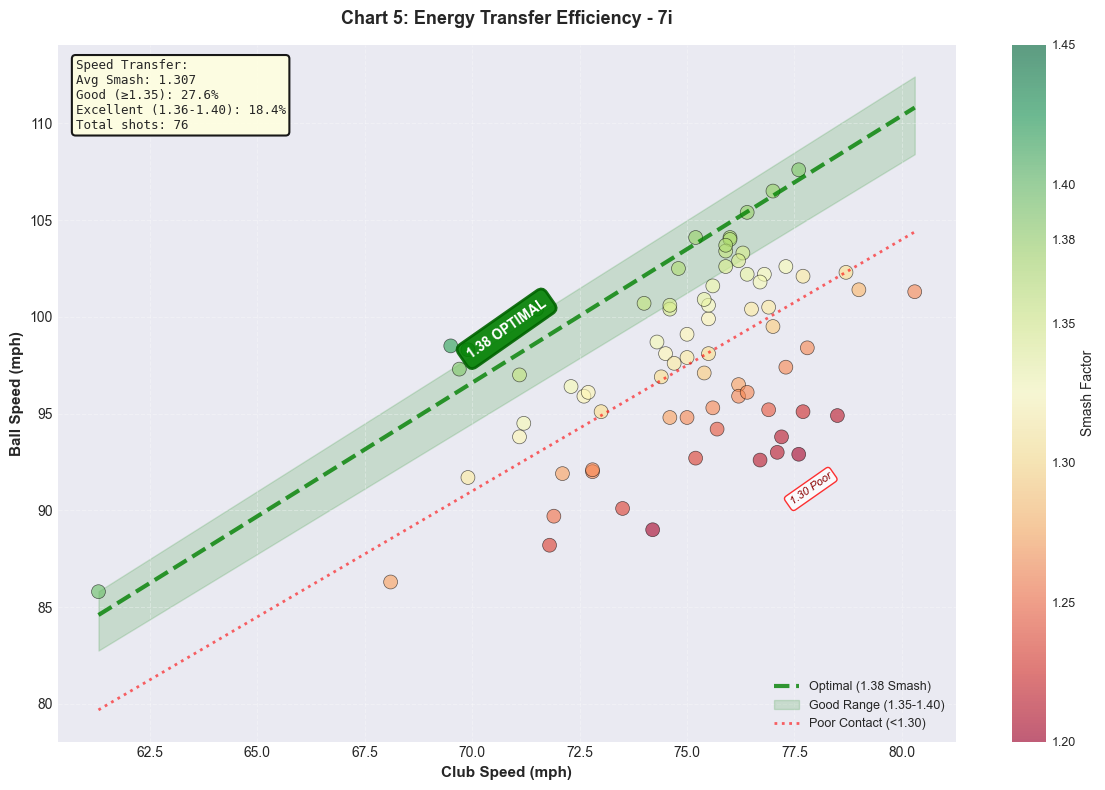

Chart 5: Speed Efficiency - Enhanced ✓


In [14]:
newline = chr(10)

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatter plot
    scatter = ax.scatter(club_data['Club Speed'], club_data['Ball Speed'],
                        c=club_data['Smash Factor'], cmap='RdYlGn',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5,
                        vmin=1.20, vmax=1.45)
    
    # Optimal smash factor line (1.38)
    if len(club_data) > 0:
        club_speed_range = np.linspace(club_data['Club Speed'].min(), club_data['Club Speed'].max(), 100)
        optimal_ball_speed = club_speed_range * 1.38
        ax.plot(club_speed_range, optimal_ball_speed, 'g--', linewidth=3, alpha=0.8, label='Optimal (1.38 Smash)', zorder=2)
        
        # Good range (1.35-1.40)
        good_upper = club_speed_range * 1.40
        good_lower = club_speed_range * 1.35
        ax.fill_between(club_speed_range, good_lower, good_upper,
                       alpha=0.15, color='green', label='Good Range (1.35-1.40)', zorder=0)
        
        # Poor range (<1.30)
        poor_line = club_speed_range * 1.30
        ax.plot(club_speed_range, poor_line, 'r:', linewidth=2, alpha=0.6, label='Poor Contact (<1.30)', zorder=1)
        
        # Label the optimal line
        mid_speed = (club_data['Club Speed'].min() + club_data['Club Speed'].max()) / 2
        ax.text(mid_speed, mid_speed*1.38, '1.38 OPTIMAL', fontsize=10, rotation=35,
                va='bottom', ha='center', fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='green', alpha=0.9, edgecolor='darkgreen', linewidth=2))
        
        # Label poor contact line
        ax.text(mid_speed*1.1, mid_speed*1.30, '1.30 Poor', fontsize=8, rotation=35,
                va='top', ha='center', style='italic', color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='red'))
    
    # Stats
    avg_smash = (club_data['Ball Speed'] / club_data['Club Speed']).mean()
    good_contact = len(club_data[club_data['Smash Factor'] >= 1.35])
    excellent_contact = len(club_data[(club_data['Smash Factor'] >= 1.36) & (club_data['Smash Factor'] <= 1.40)])
    
    stats_text = (
        f'Speed Transfer:{newline}'
        f'Avg Smash: {avg_smash:.3f}{newline}'
        f'Good (≥1.35): {100*good_contact/len(club_data):.1f}%{newline}'
        f'Excellent (1.36-1.40): {100*excellent_contact/len(club_data):.1f}%{newline}'
        f'Total shots: {len(club_data)}'
    )
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    # Formatting
    ax.set_xlabel('Club Speed (mph)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Ball Speed (mph)', fontsize=11, fontweight='bold')
    ax.set_title(f'Chart 5: Energy Transfer Efficiency - {club}', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Smash Factor')
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks([1.20, 1.25, 1.30, 1.35, 1.38, 1.40, 1.45])
    
    plt.tight_layout()
    plt.show()

print('Chart 5: Speed Efficiency - Enhanced ✓')


### Chart 6: Launch Optimization (Launch Angle vs Carry)

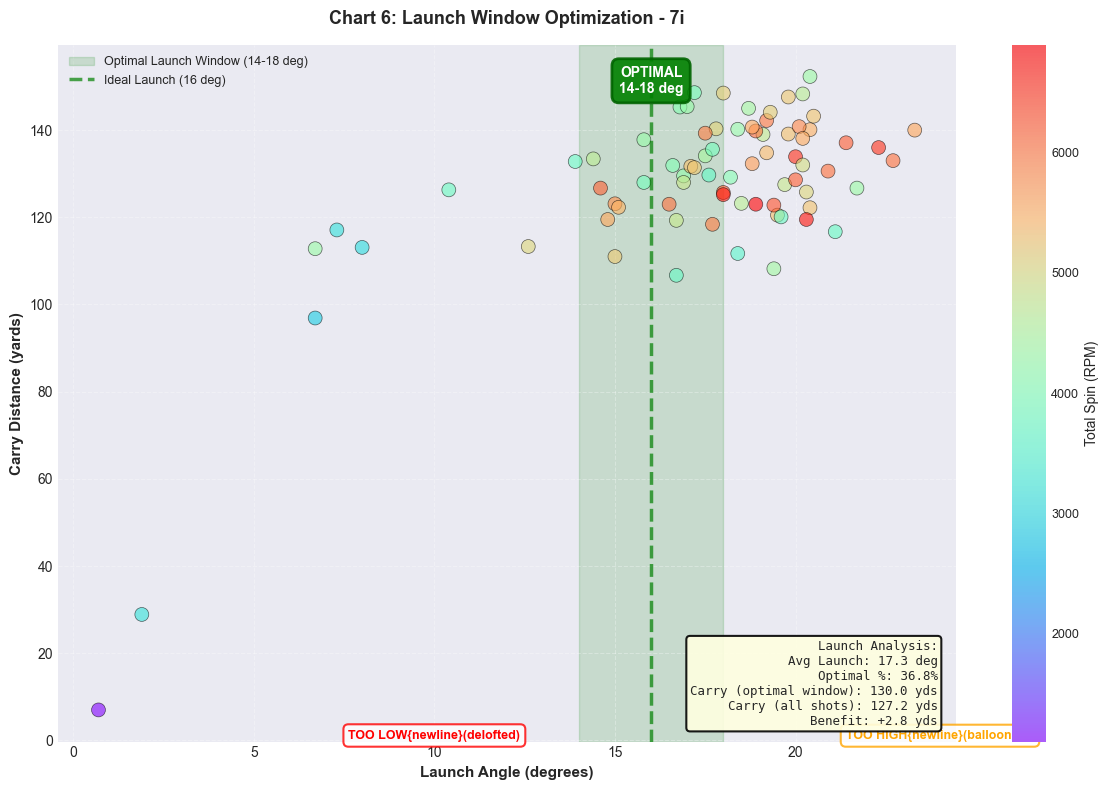

Chart 6: Launch Optimization - Enhanced ✓


In [15]:
newline = chr(10)

for club in df_clean['Club'].unique():
    club_data = df_clean[df_clean['Club'] == club]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatter plot
    scatter = ax.scatter(club_data['Launch Angle'], club_data['Carry'],
                        c=club_data['Total Spin'], cmap='rainbow',
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Optimal launch window (14-18 degrees for 7-iron)
    optimal_launch_low = 14
    optimal_launch_high = 18
    ax.axvspan(optimal_launch_low, optimal_launch_high,
              alpha=0.15, color='green', label='Optimal Launch Window (14-18 deg)', zorder=0)
    
    # Reference lines
    ax.axvline(x=16, color='green', linestyle='--', linewidth=2.5, alpha=0.7, label='Ideal Launch (16 deg)', zorder=1)
    
    # Optimal zone label
    ax.text(16, ax.get_ylim()[1]*0.97, f'OPTIMAL{newline}14-18 deg', ha='center', va='top',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='green', alpha=0.9, edgecolor='darkgreen', linewidth=2))
    
    # Problem zone indicators
    if ax.get_xlim()[0] < 12:
        ax.text(10, ax.get_ylim()[0]*1.1, 'TOO LOW{newline}(delofted)', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='red',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='red', linewidth=1.5))
    
    if ax.get_xlim()[1] > 22:
        ax.text(24, ax.get_ylim()[0]*1.1, 'TOO HIGH{newline}(ballooning)', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='orange',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='orange', linewidth=1.5))
    
    # Calculate optimal performance
    in_optimal_window = club_data[(club_data['Launch Angle'] >= optimal_launch_low) &
                                   (club_data['Launch Angle'] <= optimal_launch_high)]
    
    if len(in_optimal_window) > 0:
        avg_carry_optimal = in_optimal_window['Carry'].mean()
        avg_carry_all = club_data['Carry'].mean()
        
        stats_text = (
            f'Launch Analysis:{newline}'
            f'Avg Launch: {club_data["Launch Angle"].mean():.1f} deg{newline}'
            f'Optimal %: {100*len(in_optimal_window)/len(club_data):.1f}%{newline}'
            f'Carry (optimal window): {avg_carry_optimal:.1f} yds{newline}'
            f'Carry (all shots): {avg_carry_all:.1f} yds{newline}'
            f'Benefit: {avg_carry_optimal - avg_carry_all:+.1f} yds'
        )
    else:
        stats_text = (
            f'Launch Analysis:{newline}'
            f'Avg Launch: {club_data["Launch Angle"].mean():.1f} deg{newline}'
            f'Optimal %: 0.0%{newline}'
            f'No shots in optimal window!{newline}'
            f'Target: 14-18 deg launch'
        )
    
    ax.text(0.98, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', horizontalalignment='right', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    # Formatting
    ax.set_xlabel('Launch Angle (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Carry Distance (yards)', fontsize=11, fontweight='bold')
    ax.set_title(f'Chart 6: Launch Window Optimization - {club}', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Total Spin (RPM)')
    cbar.ax.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.show()

print('Chart 6: Launch Optimization - Enhanced ✓')


## 📈 Session-by-Session Progress Tracking

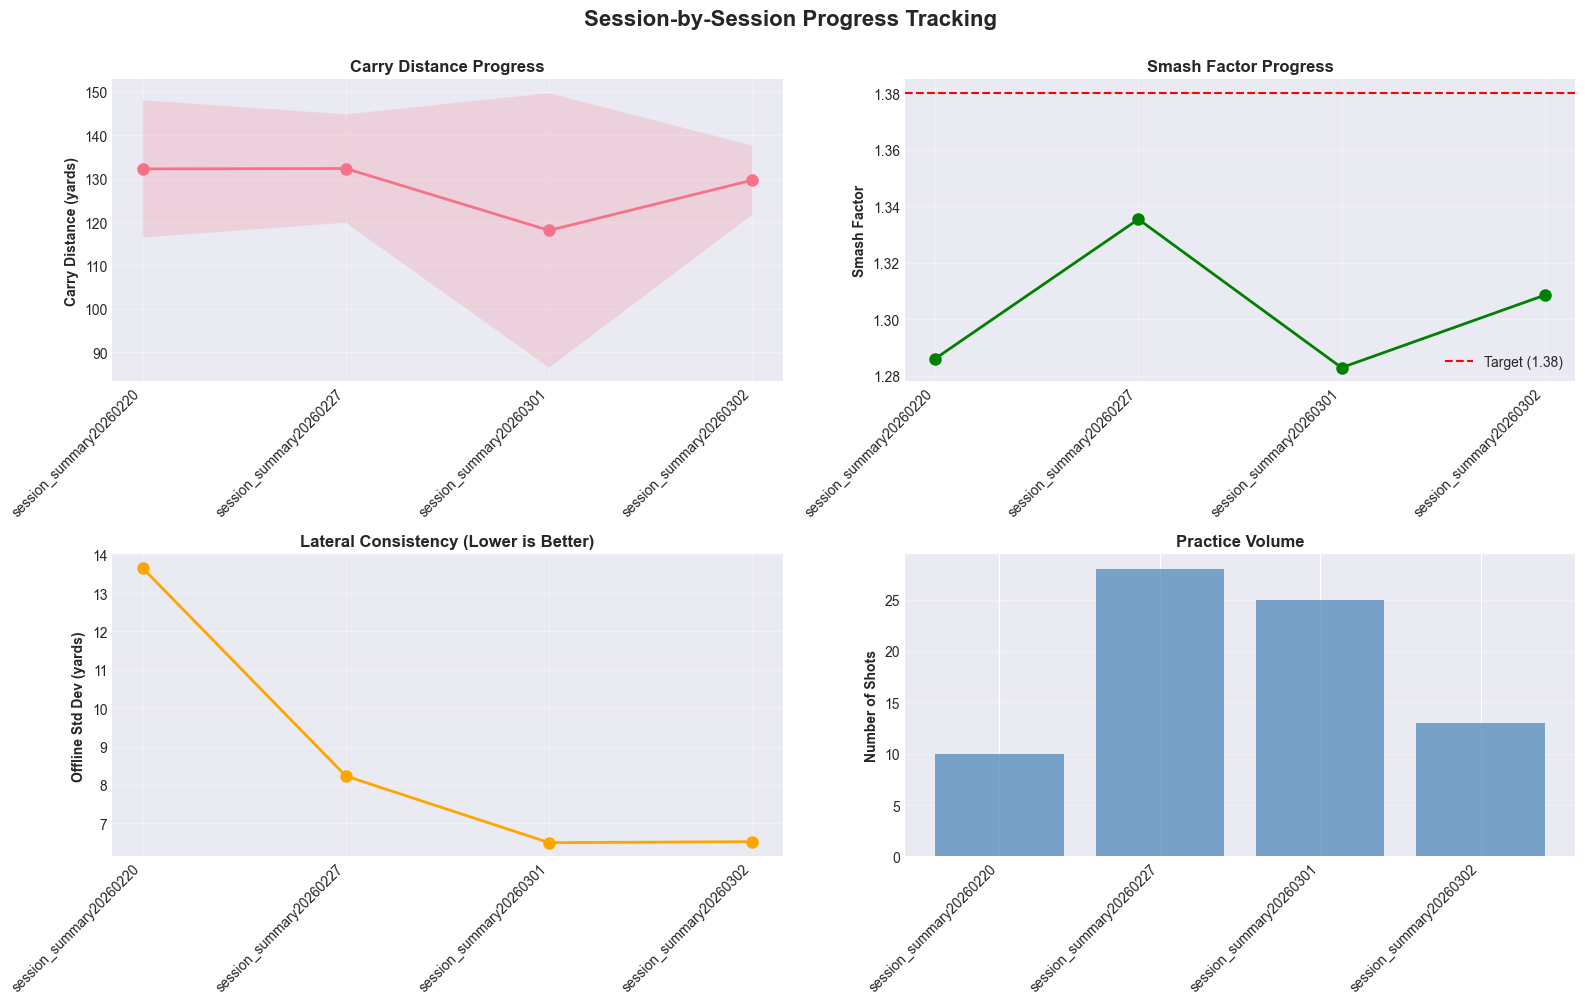


📊 Session Summary:
                Session       Date  Shots  Avg Carry  Carry Std  Avg Smash  Offline Avg  Offline Std
session_summary20260220 02/20/2026     10      132.2       15.8        1.3        -18.1         13.6
session_summary20260227 02/27/2026     28      132.3       12.5        1.3        -20.4          8.2
session_summary20260301 03/01/2026     25      118.1       31.6        1.3          5.1          6.5
session_summary20260302 03/02/2026     13      129.6        8.0        1.3         -5.7          6.5


In [16]:
# Calculate session averages
session_data = []

for session in sorted(df_clean['Session_File'].unique()):
    session_df = df_clean[df_clean['Session_File'] == session]
    
    session_data.append({
        'Session': session,
        'Date': session_df['Date'].iloc[0] if 'Date' in session_df.columns else '',
        'Shots': len(session_df),
        'Avg Carry': session_df['Carry'].mean(),
        'Carry Std': session_df['Carry'].std(),
        'Avg Smash': session_df['Smash Factor'].mean(),
        'Offline Avg': session_df['Offline'].mean(),
        'Offline Std': session_df['Offline'].abs().std(),
    })

df_sessions = pd.DataFrame(session_data)

# Plot progress
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Carry distance over time
axes[0, 0].plot(df_sessions.index, df_sessions['Avg Carry'], 'o-', linewidth=2, markersize=8)
axes[0, 0].fill_between(df_sessions.index, 
                        df_sessions['Avg Carry'] - df_sessions['Carry Std'],
                        df_sessions['Avg Carry'] + df_sessions['Carry Std'],
                        alpha=0.2)
axes[0, 0].set_ylabel('Carry Distance (yards)', fontweight='bold')
axes[0, 0].set_title('Carry Distance Progress', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(df_sessions.index)
axes[0, 0].set_xticklabels(df_sessions['Session'], rotation=45, ha='right')

# Smash factor over time
axes[0, 1].plot(df_sessions.index, df_sessions['Avg Smash'], 'o-', 
               linewidth=2, markersize=8, color='green')
axes[0, 1].axhline(y=1.38, color='red', linestyle='--', label='Target (1.38)')
axes[0, 1].set_ylabel('Smash Factor', fontweight='bold')
axes[0, 1].set_title('Smash Factor Progress', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xticks(df_sessions.index)
axes[0, 1].set_xticklabels(df_sessions['Session'], rotation=45, ha='right')

# Offline consistency
axes[1, 0].plot(df_sessions.index, df_sessions['Offline Std'], 'o-',
               linewidth=2, markersize=8, color='orange')
axes[1, 0].set_ylabel('Offline Std Dev (yards)', fontweight='bold')
axes[1, 0].set_title('Lateral Consistency (Lower is Better)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(df_sessions.index)
axes[1, 0].set_xticklabels(df_sessions['Session'], rotation=45, ha='right')

# Shot count
axes[1, 1].bar(df_sessions.index, df_sessions['Shots'], color='steelblue', alpha=0.7)
axes[1, 1].set_ylabel('Number of Shots', fontweight='bold')
axes[1, 1].set_title('Practice Volume', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_xticks(df_sessions.index)
axes[1, 1].set_xticklabels(df_sessions['Session'], rotation=45, ha='right')

plt.suptitle('Session-by-Session Progress Tracking', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n📊 Session Summary:")
print(df_sessions.to_string(index=False))

## 💡 Key Takeaways & Action Items

In [17]:
# Generate summary insights
club = df_clean['Club'].iloc[0]  # Assuming 7i
club_data = df_clean[df_clean['Club'] == club]

current_carry = club_data['Carry'].mean()
current_smash = club_data['Smash Factor'].mean()
current_club_speed = club_data['Club Speed'].mean()

# Calculate potential
if club in ['7i', '7iron']:
    tour_data = TOUR_BENCHMARKS['7i']
    targets = calculate_personalized_targets(club, current_club_speed, tour_data)
    
    potential_gain = targets['carry'] - current_carry
    
    print("="*80)
    print("🎯 YOUR IMPROVEMENT ROADMAP (7-Iron)")
    print("="*80)
    print(f"\n📍 CURRENT STATE:")
    print(f"   Carry Distance: {current_carry:.1f} yards")
    print(f"   Club Speed: {current_club_speed:.1f} mph")
    print(f"   Smash Factor: {current_smash:.2f}")
    print(f"   Speed Category: {targets['category']}")
    
    print(f"\n🎯 YOUR OPTIMAL TARGETS (at {current_club_speed:.0f} mph):")
    print(f"   Target Carry: {targets['carry']:.1f} yards")
    print(f"   Target Smash: {targets['smash']:.2f}")
    print(f"   Target Launch: {targets['launch']:.1f}°")
    print(f"   Target Spin: {targets['spin']:.0f} RPM")
    
    print(f"\n📊 IMPROVEMENT POTENTIAL:")
    print(f"   Available Distance Gain: {potential_gain:.1f} yards")
    print(f"   Smash Factor Gap: {targets['smash'] - current_smash:.2f}")
    print(f"   Primary Limiter: Contact Quality (Smash Factor)")
    
    print(f"\n✅ PRIORITY #1: Improve Smash Factor")
    print(f"   Current: {current_smash:.2f} → Target: {targets['smash']:.2f}")
    print(f"   Action: Use impact spray to find strike pattern")
    print(f"   Expected Gain: 15-20 yards with 1.35+ smash")
    
    print(f"\n📅 TIMELINE:")
    smash_1mo = min(current_smash + 0.05, 1.35)
    smash_3mo = min(current_smash + 0.09, 1.37)
    smash_6mo = min(current_smash + 0.11, targets['smash'])
    
    carry_1mo = current_carry + (smash_1mo - current_smash) * 150
    carry_3mo = current_carry + (smash_3mo - current_smash) * 150
    carry_6mo = current_carry + (smash_6mo - current_smash) * 150
    
    print(f"   1 Month:  Smash {smash_1mo:.2f} → ~{carry_1mo:.0f} yards (+{carry_1mo-current_carry:.0f})")
    print(f"   3 Months: Smash {smash_3mo:.2f} → ~{carry_3mo:.0f} yards (+{carry_3mo-current_carry:.0f})")
    print(f"   6 Months: Smash {smash_6mo:.2f} → ~{carry_6mo:.0f} yards (+{carry_6mo-current_carry:.0f})")
    
    print(f"\n🔧 NEXT PRACTICE SESSION:")
    print(f"   1. Buy impact spray or foot powder")
    print(f"   2. Hit 10 shots and check strike location")
    print(f"   3. Adjust setup/swing to center contact")
    print(f"   4. Focus on FEEL of centered strikes")
    print(f"   5. Re-test after 20 balls")
    
    print(f"\n" + "="*80)

🎯 YOUR IMPROVEMENT ROADMAP (7-Iron)

📍 CURRENT STATE:
   Carry Distance: 127.2 yards
   Club Speed: 74.8 mph
   Smash Factor: 1.31
   Speed Category: Competitive Amateur

🎯 YOUR OPTIMAL TARGETS (at 75 mph):
   Target Carry: 146.8 yards
   Target Smash: 1.38
   Target Launch: 17.3°
   Target Spin: 7452 RPM

📊 IMPROVEMENT POTENTIAL:
   Available Distance Gain: 19.6 yards
   Smash Factor Gap: 0.07
   Primary Limiter: Contact Quality (Smash Factor)

✅ PRIORITY #1: Improve Smash Factor
   Current: 1.31 → Target: 1.38
   Action: Use impact spray to find strike pattern
   Expected Gain: 15-20 yards with 1.35+ smash

📅 TIMELINE:
   1 Month:  Smash 1.35 → ~134 yards (+6)
   3 Months: Smash 1.37 → ~137 yards (+9)
   6 Months: Smash 1.38 → ~138 yards (+11)

🔧 NEXT PRACTICE SESSION:
   1. Buy impact spray or foot powder
   2. Hit 10 shots and check strike location
   3. Adjust setup/swing to center contact
   4. Focus on FEEL of centered strikes
   5. Re-test after 20 balls



## 📝 Export Summary Report

In [18]:
# Save summary to CSV for future reference
df_stats.to_csv('summary_stats.csv', index=False)
df_targets.to_csv('personalized_targets.csv', index=False)
df_sessions.to_csv('session_progress.csv', index=False)

print("✅ Summary files exported:")
print("   - summary_stats.csv")
print("   - personalized_targets.csv")
print("   - session_progress.csv")

✅ Summary files exported:
   - summary_stats.csv
   - personalized_targets.csv
   - session_progress.csv


---

## 🏁 Summary

This notebook provides comprehensive analysis of your GC3 golf data including:

✅ **Statistical Analysis** - True averages with outliers removed  
✅ **Personalized Targets** - Based on YOUR swing speed, not PGA Tour  
✅ **Swing Flaw Diagnosis** - Specific issues with fixes  
✅ **Visual Pattern Analysis** - 6 interactive charts revealing insights  
✅ **Progress Tracking** - Session-by-session improvement  
✅ **Action Plan** - Clear priorities and timeline  

**Next Steps:**
1. Focus on improving smash factor (contact quality)
2. Use impact spray to identify strike pattern
3. Re-run this notebook after 2-3 practice sessions
4. Track your color-coded progress toward targets

---

*Generated by GC3 Virtual Coach & Data Architect*

## Box Plot: Carry Distance Distribution by Club

Shows the full distribution of carry distances for each club across all sessions.

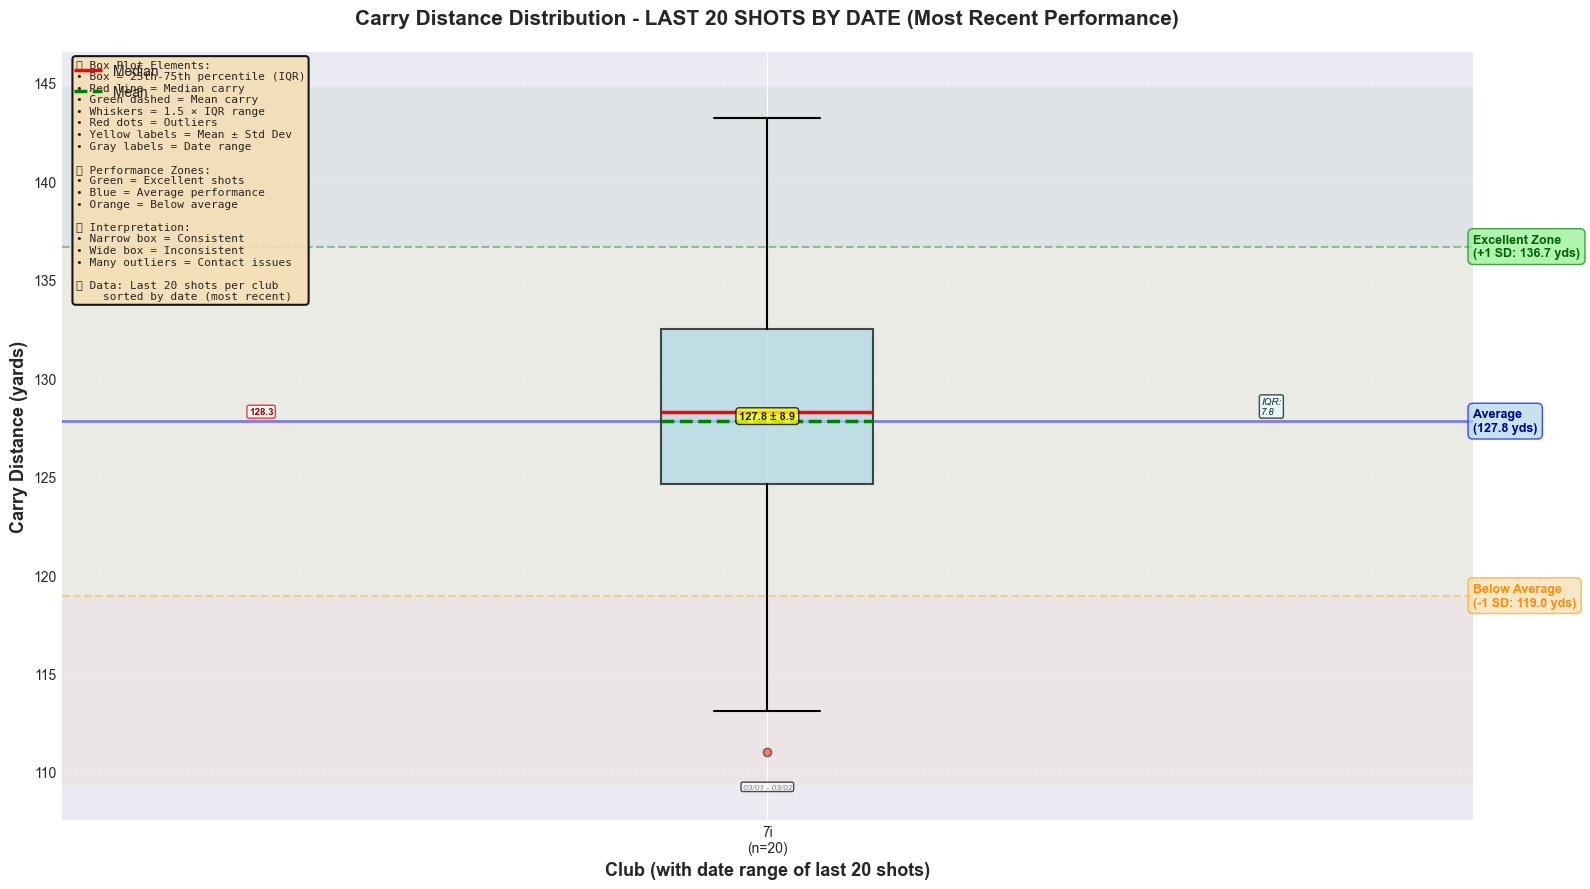


📊 Last 20 Shots Box Plot Summary (By Date):
  7i (03/01 - 03/02): Mean=127.8 | Median=128.3 | SD= 8.9 | IQR= 7.8 | n=20 | Fair

💡 This shows your MOST RECENT performance (last 20 shots by date).
   Compare this to your all-time stats to see if you're improving!


In [19]:
# Box plot for carry distance distribution - LAST 20 SHOTS BY DATE
newline = chr(10)
fig, ax = plt.subplots(figsize=(16, 9))

# Get data for each club (last 20 shots by date)
club_data_list = []
club_labels = []
club_names = []
club_date_ranges = []

for club in sorted(df_clean['Club'].unique()):
    club_shots = df_clean[df_clean['Club'] == club]
    
    # Sort by DateTime and get last 20
    if 'DateTime' in club_shots.columns:
        club_shots = club_shots.sort_values('DateTime')
    
    last_20 = club_shots.tail(20)['Carry'].dropna()
    
    if len(last_20) > 0:
        club_data_list.append(last_20)
        club_labels.append(f'{club}{newline}(n={len(last_20)})')
        club_names.append(club)
        
        # Get date range for last 20 shots
        last_20_dates = club_shots.tail(20)['DateTime']
        if len(last_20_dates) > 0 and 'DateTime' in club_shots.columns:
            date_range = f"{last_20_dates.min().strftime('%m/%d')} - {last_20_dates.max().strftime('%m/%d')}"
            club_date_ranges.append(date_range)
        else:
            club_date_ranges.append('N/A')

# Create box plot
bp = ax.boxplot(club_data_list, labels=club_labels, patch_artist=True,
                showmeans=True, meanline=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7, edgecolor='black', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2.5, label='Median'),
                meanprops=dict(color='green', linewidth=2.5, linestyle='--', label='Mean'),
                whiskerprops=dict(linewidth=1.5, color='black'),
                capprops=dict(linewidth=1.5, color='black'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))

# Add detailed annotations for each club
for i, (club_data, club_name, date_range) in enumerate(zip(club_data_list, club_names, club_date_ranges)):
    mean_val = club_data.mean()
    median_val = club_data.median()
    std_val = club_data.std()
    q1 = club_data.quantile(0.25)
    q3 = club_data.quantile(0.75)
    iqr = q3 - q1
    
    # Mean ± Std annotation (yellow box)
    ax.text(i+1, mean_val, f'{mean_val:.1f} ± {std_val:.1f}', 
            ha='center', va='bottom', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8, edgecolor='black'))
    
    # IQR annotation (light blue box on the side)
    ax.text(i+1.35, (q1+q3)/2, f'IQR:{newline}{iqr:.1f}', 
            ha='left', va='center', fontsize=7, style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightcyan', alpha=0.7))
    
    # Median value label (small red box)
    ax.text(i+0.65, median_val, f'{median_val:.1f}', 
            ha='right', va='center', fontsize=7, color='darkred', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='red'))
    
    # Date range annotation (bottom of chart)
    ax.text(i+1, ax.get_ylim()[0], date_range, 
            ha='center', va='top', fontsize=6, style='italic', color='gray',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Add horizontal reference lines for performance zones
if len(club_data_list) > 0:
    # Calculate overall mean for reference
    overall_mean = np.mean([d.mean() for d in club_data_list])
    overall_std = np.mean([d.std() for d in club_data_list])
    
    # Add performance zone lines
    excellent_line = overall_mean + overall_std
    good_line = overall_mean
    needs_work_line = overall_mean - overall_std
    
    # Excellent zone (green)
    ax.axhline(y=excellent_line, color='green', linestyle='--', linewidth=1.5, alpha=0.4, zorder=0)
    ax.text(len(club_data_list) + 0.5, excellent_line, f'Excellent Zone{newline}(+1 SD: {excellent_line:.1f} yds)', 
            va='center', ha='left', fontsize=9, color='darkgreen', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.7, edgecolor='green'))
    
    # Average line (blue)
    ax.axhline(y=good_line, color='blue', linestyle='-', linewidth=2, alpha=0.5, zorder=0)
    ax.text(len(club_data_list) + 0.5, good_line, f'Average{newline}({good_line:.1f} yds)', 
            va='center', ha='left', fontsize=9, color='darkblue', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7, edgecolor='blue'))
    
    # Needs work zone (orange)
    ax.axhline(y=needs_work_line, color='orange', linestyle='--', linewidth=1.5, alpha=0.4, zorder=0)
    ax.text(len(club_data_list) + 0.5, needs_work_line, f'Below Average{newline}(-1 SD: {needs_work_line:.1f} yds)', 
            va='center', ha='left', fontsize=9, color='darkorange', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.7, edgecolor='orange'))

# Add consistency zone highlighting (background shading)
ax.axhspan(excellent_line, ax.get_ylim()[1], facecolor='green', alpha=0.05, zorder=0)
ax.axhspan(needs_work_line, excellent_line, facecolor='yellow', alpha=0.05, zorder=0)
ax.axhspan(ax.get_ylim()[0], needs_work_line, facecolor='orange', alpha=0.05, zorder=0)

# Formatting
ax.set_xlabel('Club (with date range of last 20 shots)', fontsize=13, fontweight='bold')
ax.set_ylabel('Carry Distance (yards)', fontsize=13, fontweight='bold')
ax.set_title('Carry Distance Distribution - LAST 20 SHOTS BY DATE (Most Recent Performance)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Add detailed interpretation guide
interpretation = (
    f'📊 Box Plot Elements:{newline}'
    f'• Box = 25th-75th percentile (IQR){newline}'
    f'• Red line = Median carry{newline}'
    f'• Green dashed = Mean carry{newline}'
    f'• Whiskers = 1.5 × IQR range{newline}'
    f'• Red dots = Outliers{newline}'
    f'• Yellow labels = Mean ± Std Dev{newline}'
    f'• Gray labels = Date range{newline}'
    f'{newline}'
    f'🎯 Performance Zones:{newline}'
    f'• Green = Excellent shots{newline}'
    f'• Blue = Average performance{newline}'
    f'• Orange = Below average{newline}'
    f'{newline}'
    f'💡 Interpretation:{newline}'
    f'• Narrow box = Consistent{newline}'
    f'• Wide box = Inconsistent{newline}'
    f'• Many outliers = Contact issues{newline}'
    f'{newline}'
    f'📅 Data: Last 20 shots per club{newline}'
    f'    sorted by date (most recent)'
)
ax.text(0.01, 0.99, interpretation, transform=ax.transAxes,
        fontsize=8, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=1.5))

plt.tight_layout()
plt.show()

print(f"{newline}📊 Last 20 Shots Box Plot Summary (By Date):")
print(f"{'='*90}")
for club_name, club_data, date_range in zip(club_names, club_data_list, club_date_ranges):
    mean_val = club_data.mean()
    median_val = club_data.median()
    std_val = club_data.std()
    iqr_val = club_data.quantile(0.75) - club_data.quantile(0.25)
    consistency = 'Excellent' if std_val < 5 else 'Good' if std_val < 8 else 'Fair' if std_val < 12 else 'Needs Work'
    print(f"{club_name:>4} ({date_range}): Mean={mean_val:5.1f} | Median={median_val:5.1f} | SD={std_val:4.1f} | IQR={iqr_val:4.1f} | n={len(club_data):2} | {consistency}")
print(f"{'='*90}")
print(f"{newline}💡 This shows your MOST RECENT performance (last 20 shots by date).")
print(f"   Compare this to your all-time stats to see if you're improving!")
